## Step 1: Load the Data
We load the training and test datasets to see what we're working with.

In [1]:
import pandas as pd

train = pd.read_csv("training.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (7094, 37)
Test shape: (2365, 32)


,ID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8_1,Q8_2,...,Q17,Q18,Q19,Latitude,Longitude,mobile_money,savings,borrowing,insurance,mobile_money_classification
0,5086,98,2,3,1,1,2,2,0,0,...,-1,4,4,-4.460442,29.811396,0,0,0,0,0
1,1258,40,1,1,3,5,1,1,1,0,...,4,1,4,-6.176438,39.244871,1,1,1,0,3
2,331,18,2,4,6,3,2,1,0,0,...,-1,1,1,-6.825702,37.652798,1,0,0,0,2
3,6729,50,1,1,3,1,1,1,0,0,...,-1,1,4,-3.372049,35.808307,1,0,1,0,3
4,8671,34,1,1,1,1,2,1,0,1,...,-1,1,4,-7.179645,31.039095,1,1,0,1,3


## Step 2: Understanding the Data

We have **7094 rows** (people) in training and **2365 rows** in test.
Each row = one person surveyed in Tanzania in the FinScope 2017 survey.
Each column = one survey question.

### What the columns mean:
- **ID** — unique respondent ID
- **Q1** — age (number)
- **Q2** — gender (1=Male, 2=Female)
- **Q3** — marital status (1=Married, 2=Divorced, 3=Widowed, 4=Single)
- **Q4** — highest education (1=None → 6=University, 7=Don't know)
- **Q5** — land ownership situation (1=Own alone → 6=Don't know)
- **Q6** — owns other land with certificate? (1=Yes, 2=No)
- **Q7** — owns a mobile phone? (1=Yes, 2=No)
- **Q8_1 to Q8_11** — income sources (1=Yes, 0=No each):
  - Q8_1=Salary, Q8_2=Trading, Q8_3=Services, Q8_4=Casual labor,
  - Q8_5=Rent, Q8_6=Interest/investments, Q8_7=Pension,
  - Q8_8=Government grant, Q8_9=Relies on others, Q8_10=Someone pays expenses, Q8_11=Other
- **Q9** — employer type (only for salaried people, -1=not applicable)
- **Q10** — what they mainly sell (only for traders, -1=not applicable)
- **Q11** — what service they mainly provide (-1=not applicable)
- **Q12** — sent money to another place in past 12 months? (1=Yes, 2=No)
- **Q13** — when last sent money (-1=not applicable)
- **Q14** — received money from another place in past 12 months? (1=Yes, 2=No)
- **Q15** — when last received money (-1=not applicable)
- **Q16** — how often used mobile money for purchases (-1=not applicable)
- **Q17** — how often used mobile money for bill payments (-1=not applicable)
- **Q18** — literacy in Kiswahili (1=Read & write → 5=Refused)
- **Q19** — literacy in English (1=Read & write → 5=Refused)
- **Latitude / Longitude** — approximate GPS location of respondent
- **mobile_money** — uses mobile money? (1=Yes, 0=No)
- **savings** — saves formally? (1=Yes, 0=No)
- **borrowing** — borrows formally? (1=Yes, 0=No)
- **insurance** — has insurance? (1=Yes, 0=No)

###  Target column: mobile_money_classification
- **0** = No financial services at all
- **1** = No mobile money, but has savings/credit/insurance
- **2** = Mobile money only
- **3** = Mobile money + at least one other service

## Step 3: Explore the Data
Let's check the target distribution and look for missing values.

In [2]:
# How many people fall in each category?
print(train["mobile_money_classification"].value_counts())
print()

# Any missing values?
print(train.isnull().sum())

mobile_money_classification
3    3126
1    1778
0    1386
2     804
Name: count, dtype: int64

ID                             0
Q1                             0
Q2                             0
Q3                             0
Q4                             0
Q5                             0
Q6                             0
Q7                             0
Q8_1                           0
Q8_2                           0
Q8_3                           0
Q8_4                           0
Q8_5                           0
Q8_6                           0
Q8_7                           0
Q8_8                           0
Q8_9                           0
Q8_10                          0
Q8_11                          0
Q9                             0
Q10                            0
Q11                            0
Q12                            0
Q13                            0
Q14                            0
Q15                            0
Q16                            0
Q17           

## Step 4: Explore the Data Distributions
We use `.describe()` to get statistics for every column,
then a histogram to see how each feature is distributed.

In [3]:
train.describe()

,ID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8_1,Q8_2,...,Q17,Q18,Q19,Latitude,Longitude,mobile_money,savings,borrowing,insurance,mobile_money_classification
count,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,...,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000,7094.000000
mean,4742.627291,38.239498,1.559910,1.787426,3.060051,2.548915,1.840569,1.397942,0.062165,0.630110,...,-0.431914,1.860164,3.163378,-6.034378,35.354029,0.553989,0.461517,0.432901,0.151255,1.799267
std,2731.120086,16.332148,0.496433,1.165160,1.557779,1.534257,0.366103,0.489508,0.241472,0.482809,...,1.489879,1.351372,1.317691,2.720888,2.899511,0.497112,0.498552,0.495512,0.358322,1.196955
min,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,-1.000000,1.000000,1.000000,-11.467463,29.639578,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2397.250000,25.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,0.000000,0.000000,...,-1.000000,1.000000,2.000000,-8.275387,32.935429,0.000000,0.000000,0.000000,0.000000,1.000000
50%,4744.500000,35.000000,2.000000,1.000000,3.000000,3.000000,2.000000,1.000000,0.000000,1.000000,...,-1.000000,1.000000,4.000000,-6.087854,35.073326,1.000000,0.000000,0.000000,0.000000,2.000000
75%,7105.000000,48.000000,2.000000,3.000000,3.000000,4.000000,2.000000,2.000000,0.000000,1.000000,...,-1.000000,4.000000,4.000000,-3.517053,38.351815,1.000000,1.000000,1.000000,0.000000,3.000000
max,9459.000000,100.000000,2.000000,4.000000,8.000000,6.000000,2.000000,2.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,-1.084000,40.258744,1.000000,1.000000,1.000000,1.000000,3.000000


## What We Notice from .describe()

### Q1 - Age
- People range from 16 to 100 years old
- Average age is 38 — mostly working-age adults in the survey

### Q2 - Gender
- Mean is 1.56 — meaning slightly more females than males in the survey




In [7]:
import matplotlib.pyplot as plt

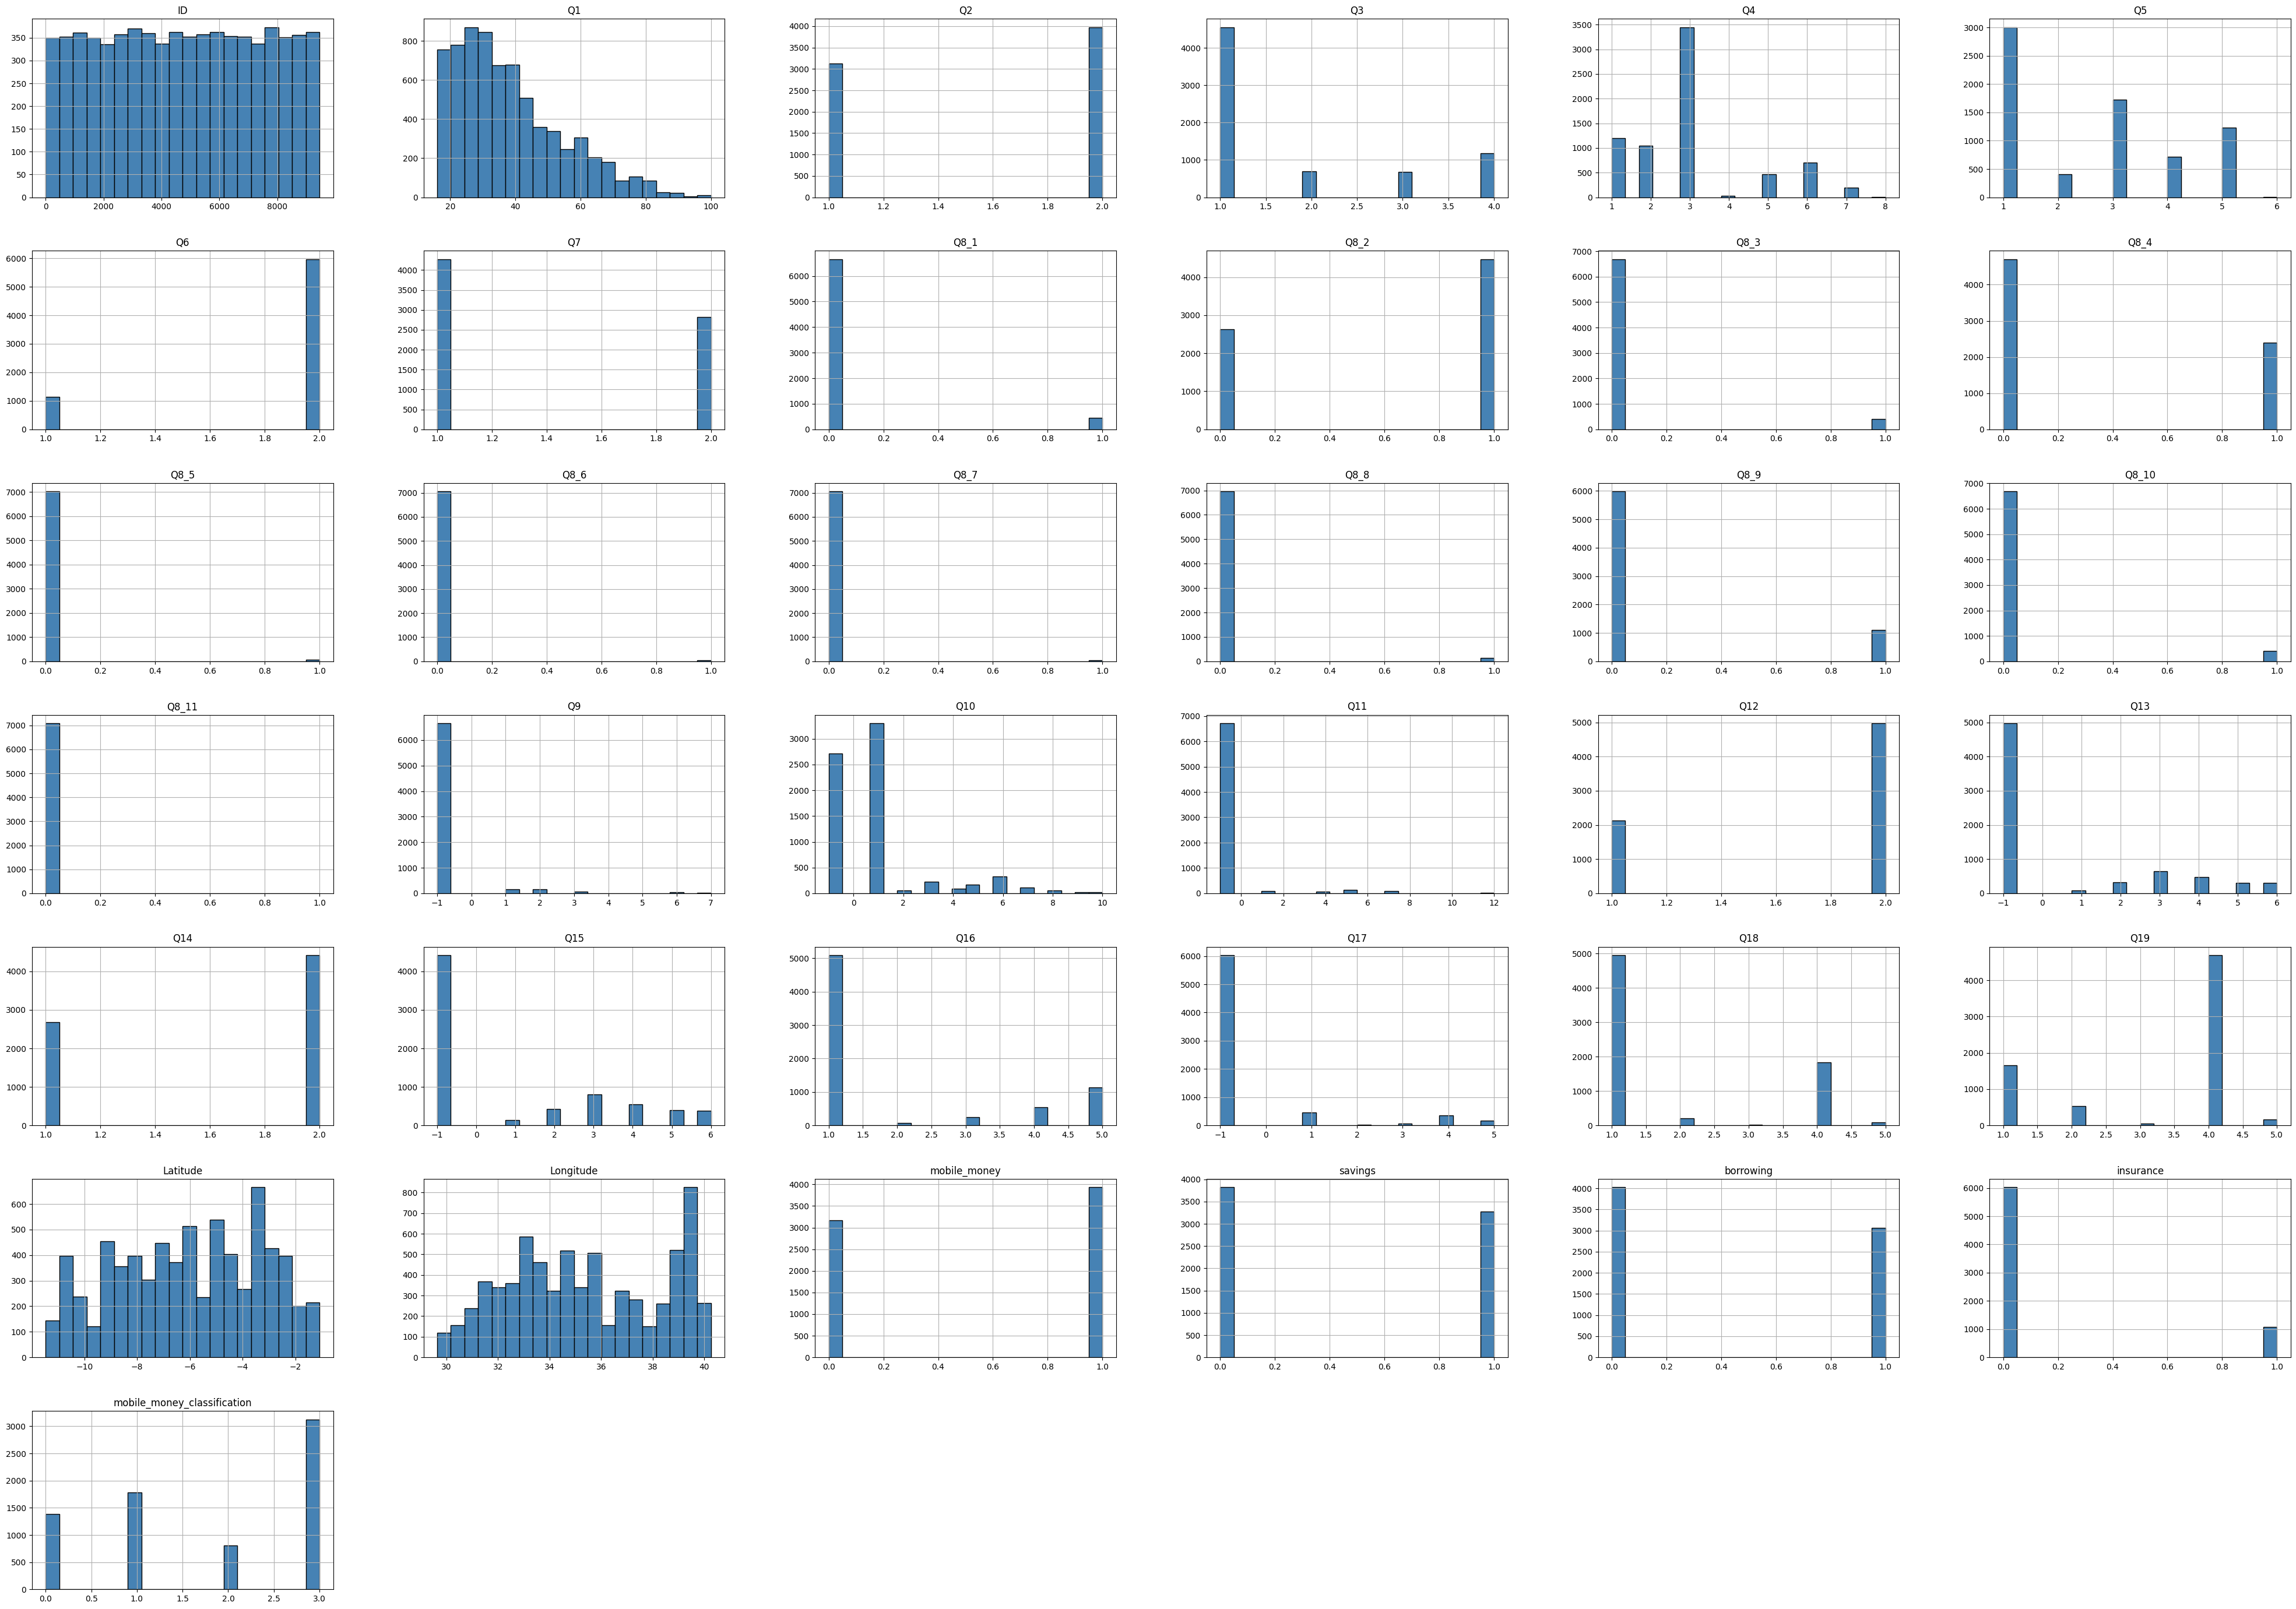

In [13]:
train.hist(figsize=(50, 35), bins=20, color="steelblue", edgecolor="black")
plt.show()


## Step 5: What the Histograms Tell Us

- **Q1 (Age)** — most people are young, bars get shorter as age increases
- **Most Q columns (Q2, Q3, Q4... Q17 etc)** — big spikes at specific values
  because these are survey questions with fixed answer choices (e.g. 1, 2, 3, 4)
  not continuous numbers. This is totally normal for survey data.



In [34]:
print(test.columns.tolist())

['ID', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8_1', 'Q8_2', 'Q8_3', 'Q8_4', 'Q8_5', 'Q8_6', 'Q8_7', 'Q8_8', 'Q8_9', 'Q8_10', 'Q8_11', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Latitude', 'Longitude']


## Why We Drop These Columns

- **ID** — just a unique number to identify each person, 
  carries no useful information for prediction

- **mobile_money_classification** — this IS our target (y), 
  we can't use it as a feature to predict itself

- **mobile_money, savings, borrowing, insurance** — these are not in the test set

In [26]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["ID", "mobile_money_classification", 
                         "mobile_money", "savings", "borrowing", "insurance"])
y = train["mobile_money_classification"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y shape:", y.shape)

X shape: (7094, 31)
X_test shape: (2365, 31)
y shape: (7094,)


In [16]:
!pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 3.0 MB/s  0:00:36m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 1.6 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Step 7: Build the Pipeline

We will use CatBoost Classifier inside a sklearn Pipeline.
A pipeline chains steps together so we don't have to do them manually each time.

CatBoost is great for this dataset because:
- 

In [17]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

pipeline = Pipeline([
    ("model", CatBoostClassifier(random_state=42))
])

print(pipeline)

Pipeline(steps=[('model', CatBoostClassifier(random_state=42))])


## Step 8: Train the Model

We fit the pipeline on our training data.
This is where the model learns patterns from the 7094 people.

In [28]:

pipeline.fit(X_train,y_train)

Learning rate set to 0.086452
0:	learn: 1.2981635	total: 53.8ms	remaining: 53.8s
1:	learn: 1.2265606	total: 82.9ms	remaining: 41.4s
2:	learn: 1.1708467	total: 104ms	remaining: 34.5s
3:	learn: 1.1203550	total: 120ms	remaining: 29.8s
4:	learn: 1.0786266	total: 134ms	remaining: 26.8s
5:	learn: 1.0435307	total: 158ms	remaining: 26.1s
6:	learn: 1.0131658	total: 189ms	remaining: 26.8s
7:	learn: 0.9869752	total: 209ms	remaining: 25.9s
8:	learn: 0.9637209	total: 233ms	remaining: 25.7s
9:	learn: 0.9451656	total: 300ms	remaining: 29.7s
10:	learn: 0.9280519	total: 320ms	remaining: 28.8s
11:	learn: 0.9117535	total: 350ms	remaining: 28.8s
12:	learn: 0.8974898	total: 380ms	remaining: 28.8s
13:	learn: 0.8856592	total: 403ms	remaining: 28.4s
14:	learn: 0.8756257	total: 441ms	remaining: 29s
15:	learn: 0.8647734	total: 471ms	remaining: 28.9s
16:	learn: 0.8552699	total: 499ms	remaining: 28.8s
17:	learn: 0.8462160	total: 515ms	remaining: 28.1s
18:	learn: 0.8376735	total: 529ms	remaining: 27.3s
19:	learn: 

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False


## Step 9: Evaluate the Model

We check how accurate the model is on the training data.
This tells us if the model learned the patterns correctly.

In [35]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipeline.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))
print()

print(classification_report(y, y_pred))

Accuracy: 0.8576261629546096

              precision    recall  f1-score   support

           0       0.84      0.75      0.79      1386
           1       0.78      0.88      0.83      1778
           2       0.92      0.61      0.73       804
           3       0.90      0.96      0.93      3126

    accuracy                           0.86      7094
   macro avg       0.86      0.80      0.82      7094
weighted avg       0.86      0.86      0.85      7094



## Step 10: Confusion Matrix

A confusion matrix shows us exactly where the model is getting 
things right and where it is making mistakes.
Each row = the actual class
Each column = what the model predicted
The diagonal = correct predictions

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[1124  243    2   17]
 [ 101 1647    1   29]
 [  13   35  521  235]
 [  27   69    3 3027]]


## Step 10: Confusion Matrix Results

Row 1: 101 + 1647 + 1 + 29 = 1778 — matches class 1
Row 2: 13 + 35 + 521 + 235 = 804 — matches class 2
Row 3: 27 + 69 + 3 + 3027 = 3126 — matches class 3

Reading the diagonal (correct predictions):
- Class 0 (No services): 1124 correct out of 1386
- Class 1 (Other only): 1647 correct out of 1778
- Class 2 (MM only): 521 correct out of 804
- Class 3 (MM + other): 3027 correct out of 3126

The model struggles most with Class 2  — 
235 were predicted wrong
This makes sense since Class 2 had the least data (only 804 people)

## Step 11: Precision & Recall

- **Precision** — of all the people the model predicted as class X, 
  how many were actually class X?
- **Recall** — of all the actual people in class X, 
  how many did the model correctly find?
- **F1 score** — a balance between precision and recall

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y, y_pred, average=None))
print("Recall:   ", recall_score(y, y_pred, average=None))
print("F1 Score: ", f1_score(y, y_pred, average=None))

Precision: [0.88853755 0.82597793 0.9886148  0.91505441]
Recall:    [0.81096681 0.92632171 0.64800995 0.96833013]
F1 Score:  [0.84798189 0.87327678 0.78287002 0.94093876]


Class 2 has very high precision (0.99) but low recall (0.65) — the model is very careful when predicting it but misses many actual people in that class
Class 3 is the best overall with recall of 0.97
Class 0 and 1 is okay

## ROC Curve

The ROC curve shows how well the model separates each class.


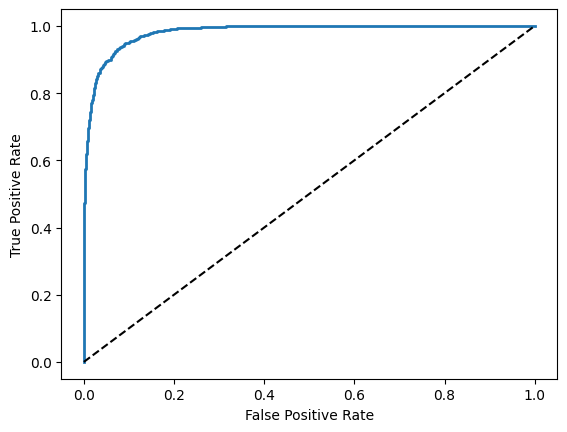

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# get the probability scores for class 0
y_prob = pipeline.predict_proba(X)[:, 0]

# y == 0 gives True/False, astype(int) converts it to 1/0
# so roc_curve knows who actually belongs to class 0 and who doesnt
fpr, tpr, thresholds = roc_curve((y == 0).astype(int), y_prob)

# plot the ROC curve
plt.plot(fpr, tpr, linewidth=2)

# plot the diagonal line (random guessing baseline)
plt.plot([0, 1], [0, 1], 'k--')

# label the axes
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# show the plot
plt.show()

## Save the Model

We save the trained model to disk so we don't have to retrain it every time.

In [31]:
import joblib

joblib.dump(pipeline, "model.pkl")
print("Model saved!")

Model saved!


In [32]:
X_test=pd.read_csv("test.csv")

In [33]:
probabilities = pipeline.predict_proba(X_test)

submission = pd.DataFrame({
    "ID": test["ID"],
    "no_financial_services": probabilities[:, 0],
    "other_only": probabilities[:, 1],
    "mm_only": probabilities[:, 2],
    "mm_plus": probabilities[:, 3]
})

submission.to_csv("submission.csv", index=False)
print("Done!")
print(submission.head())



Done!
     ID  no_financial_services  other_only   mm_only   mm_plus
0  2352               0.000024    0.000051  0.175316  0.824610
1  8208               0.005604    0.033391  0.089433  0.871572
2  2785               0.000019    0.000292  0.094405  0.905283
3  2967               0.515134    0.346358  0.010954  0.127554
4  1697               0.000119    0.000375  0.060071  0.939435
